## Virtual Moving Test 2 (V2V) Plotting Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = 'D91E'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { 'D91E': [static_focusing_slaves[0], static_focusing_slaves[1]],
                                '0090': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['DB00', '069B']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                                '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 3, 2
VEH_NAME_MAP = {3: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
test_preset_map = defaultdict(dict)
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, 
                                                                                    "Moving Test 2 (Virtual Vehicle)", 
                                                                                    "V2", 
                                                                                    CALIBRATED_CAM_TO_V2B,
                                                                                    skiptests=skiptests)
assert(len(all_test_files) == len(ground_truth_list))
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = ground_truth_list[2*i]
virtual_moving_tests = {}

In [2]:
def plot_single_test_data(raw_name):
    parsing_results = virtual_moving_tests.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return

    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins

    ######################################################
    ########## Original Results ##########
    ######################################################
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    if "moving" in raw_name.split("-v2-")[0]:
        titlename = "Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    elif "virtual" in raw_name.split("-v2-")[0]:
        titlename = "Virtual Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    elif "static" in raw_name.split("-v2-")[0]:
        static_surveyed_dist = df_static_time_idx["Surveyed Distance (mm)"].get(0, float('nan'))
        titlename = "Static Test - " + raw_name.split("-v2-")[-1]  + " - " + str(int(static_surveyed_dist)) + "mm"
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
                
    print("plotting: " + raw_name)
    ######################################################
    # Plotting individual tests
    ######################################################
    
    plot_time_series_dist(figure=figure,
                          arrange_spec=411,
                          static_veh_df=df_static_time_idx,
                          moving_veh_df=df_moving_time_idx,
                          static_veh=STATIC_VEH,
                          moving_veh=MOVING_VEH,
                          df_outlier=df_outlier_overall,
                          surveyed_static_ground_truth_value=None,
                          moving_ground_truth_df=moving_ground_truth_df,
                          scatter=True)

    plot_upd_rate(figure=figure,
                  arrange_spec=412,
                  static_veh_df=df_static_time_idx,
                  moving_veh_df=df_moving_time_idx,
                  static_veh=STATIC_VEH,
                  moving_veh=MOVING_VEH,
                  moving_ground_truth_df=moving_ground_truth_df,
                  scatter=True)

    # Instant Speed UWB Strict
    # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
    plot_time_series_speed(figure=figure, 
                           arrange_spec=413, 
                           static_veh_df=df_static_time_idx, 
                           moving_veh_df=df_moving_time_idx,
                           static_veh=STATIC_VEH,
                           moving_veh=MOVING_VEH,
                           moving_ground_truth_df=moving_ground_truth_df,
                           scatter=True)
    
    plot_real_time_moving_errors(figure=figure, 
                                 arrange_spec=414, 
                                 static_veh_df=df_static_time_idx, 
                                 moving_veh_df=df_moving_time_idx,
                                 static_veh=STATIC_VEH,
                                 moving_veh=MOVING_VEH,
                                 moving_ground_truth_df=moving_ground_truth_df,
                                 scatter=True)
    
    ######################################################
    ########## Error Histogram ##########
    ######################################################
    
    titlename = "Histogram of Real-Time Measurement Errors (Interpolated)"
    figure_hist = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    figure_hist.suptitle(titlename, fontsize='x-large', fontweight='bold')
    plot_hist_moving_err_hbar(figure=figure_hist,
                         static_veh=STATIC_VEH,
                         moving_veh=MOVING_VEH,
                         real_time_err_static_veh=df_static_time_idx['Error (mm)'],
                         real_time_err_moving_veh=df_moving_time_idx['Error (mm)'],
                         bin_size_static=static_bins,
                         bin_size_moving=moving_bins
                         )
    
    ######################################################
    ########## RESAMPLED RESULTS ##########
    ######################################################
    figure_resample = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    titlename = titlename + "-Resampled"
    figure_resample.suptitle(titlename, fontsize='x-large', fontweight='bold')
    plot_time_series_dist(figure=figure_resample,
                          arrange_spec=411,
                          static_veh_df=df_static_time_idx,
                          moving_veh_df=df_moving_time_idx,
                          static_veh=STATIC_VEH,
                          moving_veh=MOVING_VEH,
                          df_outlier=df_outlier_overall,
                          surveyed_static_ground_truth_value=None,
                          moving_ground_truth_df=moving_ground_truth_df,
                          resample=True,
                          scatter=False)

    plot_upd_rate(figure=figure_resample,
                  arrange_spec=412,
                  static_veh_df=df_static_time_idx,
                  moving_veh_df=df_moving_time_idx,
                  static_veh=STATIC_VEH,
                  moving_veh=MOVING_VEH,
                  moving_ground_truth_df=moving_ground_truth_df,
                  resample=True,
                  scatter=False)

    # Instant Speed UWB Strict
    # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
    plot_time_series_speed(figure=figure_resample, 
                           arrange_spec=413, 
                           static_veh_df=df_static_time_idx, 
                           moving_veh_df=df_moving_time_idx,
                           static_veh=STATIC_VEH,
                           moving_veh=MOVING_VEH,
                           moving_ground_truth_df=moving_ground_truth_df,
                           resample=True,
                           scatter=False)
    
    figure.tight_layout(pad=1.0)
    figure_hist.tight_layout(pad=1.0)
    figure_resample.tight_layout(pad=1.0)
    plt.show()
    

In [3]:
test_4_west = all_test_names[6]
virtual_moving_tests[test_4_west] = parse_single_test_data(test_raw_name_file_map[test_4_west]["B"],"Virtual Moving Test", 
                                                           test_raw_name_file_map[test_4_west]["ground_truth"])
plot_single_test_data(test_4_west)

processing: 2021-05-25-13-14-27-v2-4-west-20mph


KeyError: 2

## 2021-05-25-13-00-19-v2-1-west

processing: 2021-05-25-13-00-19-v2-1-west
plotting: 2021-05-25-13-00-19-v2-1-west


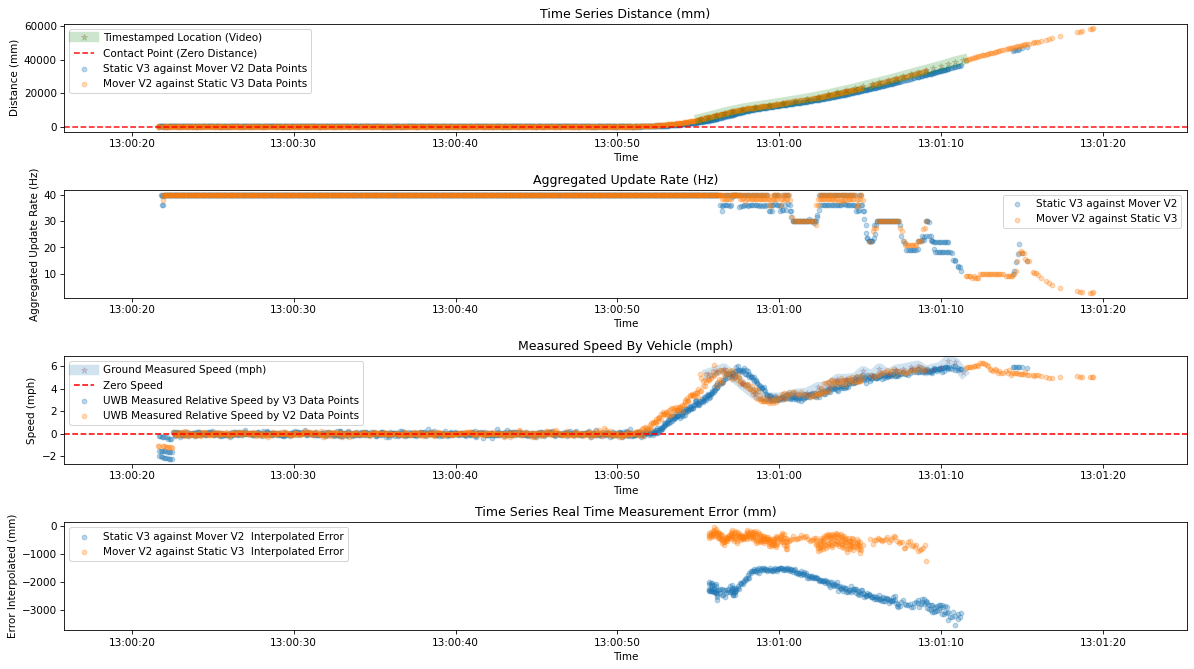

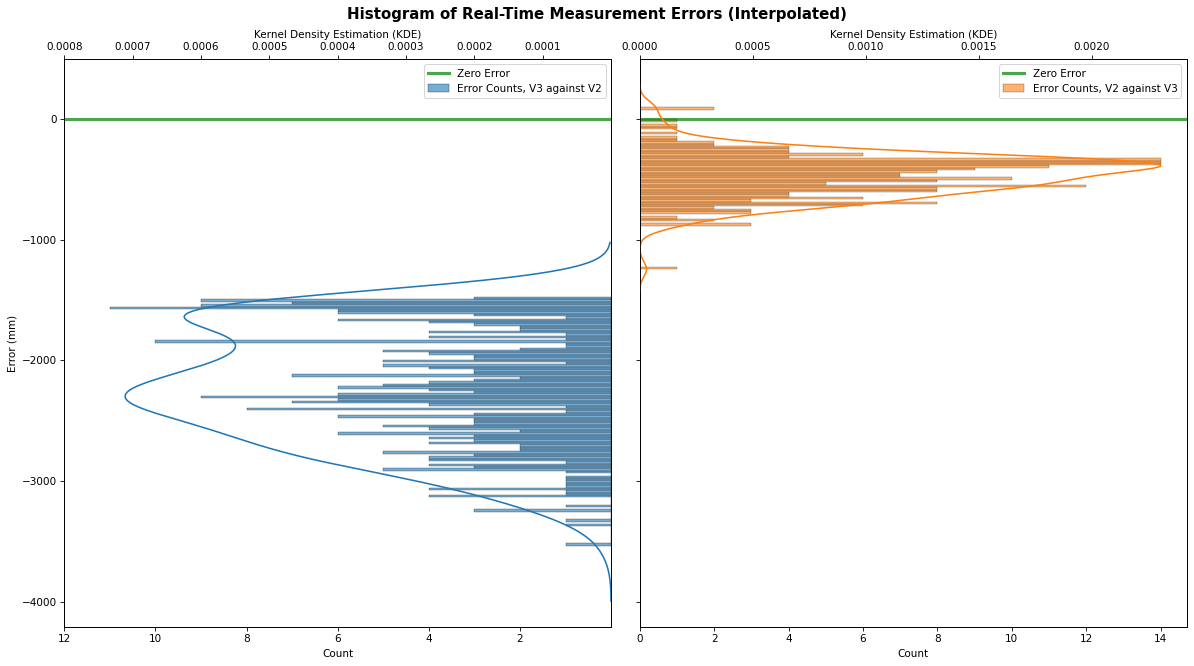

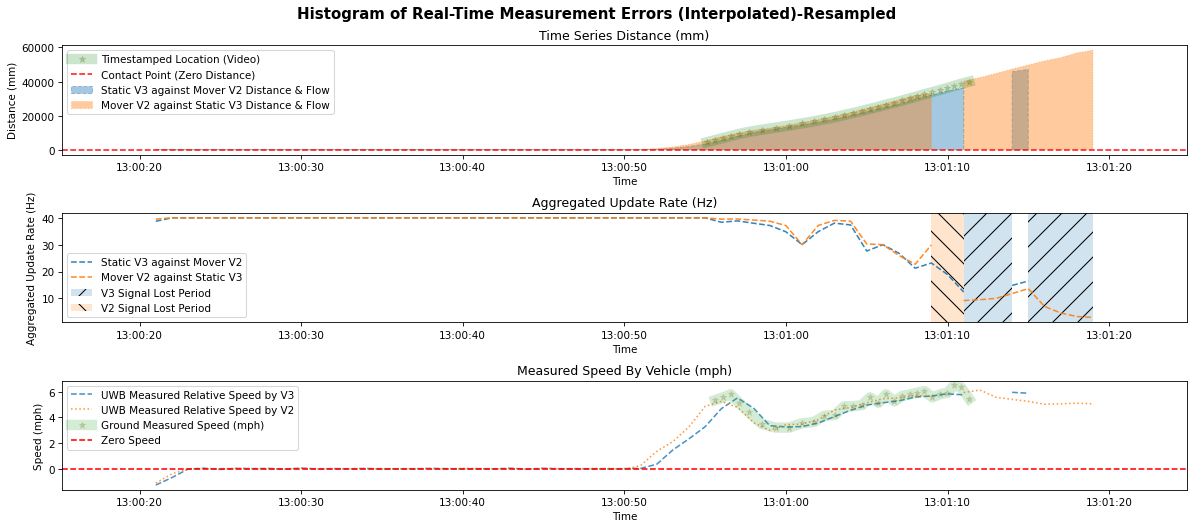

In [ ]:
test_1_west = all_test_names[0]
virtual_moving_tests[test_1_west] = parse_single_test_data(test_raw_name_file_map[test_1_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_1_west]["ground_truth"])
plot_single_test_data(test_1_west)

## 2021-05-25-13-01-56-v2-1-east

In [ ]:
test_1_east = all_test_names[1]
virtual_moving_tests[test_1_east] = parse_single_test_data(test_raw_name_file_map[test_1_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_1_east]["ground_truth"])
plot_single_test_data(test_1_east)

processing: 2021-05-25-13-01-56-v2-1-east
2021-05-25-13-01-56-v2-1-east No Data
2021-05-25-13-01-56-v2-1-east No Data, Not Plotting


## 2021-05-25-13-07-12-v2-2-west-10mph

processing: 2021-05-25-13-07-12-v2-2-west-10mph
plotting: 2021-05-25-13-07-12-v2-2-west-10mph


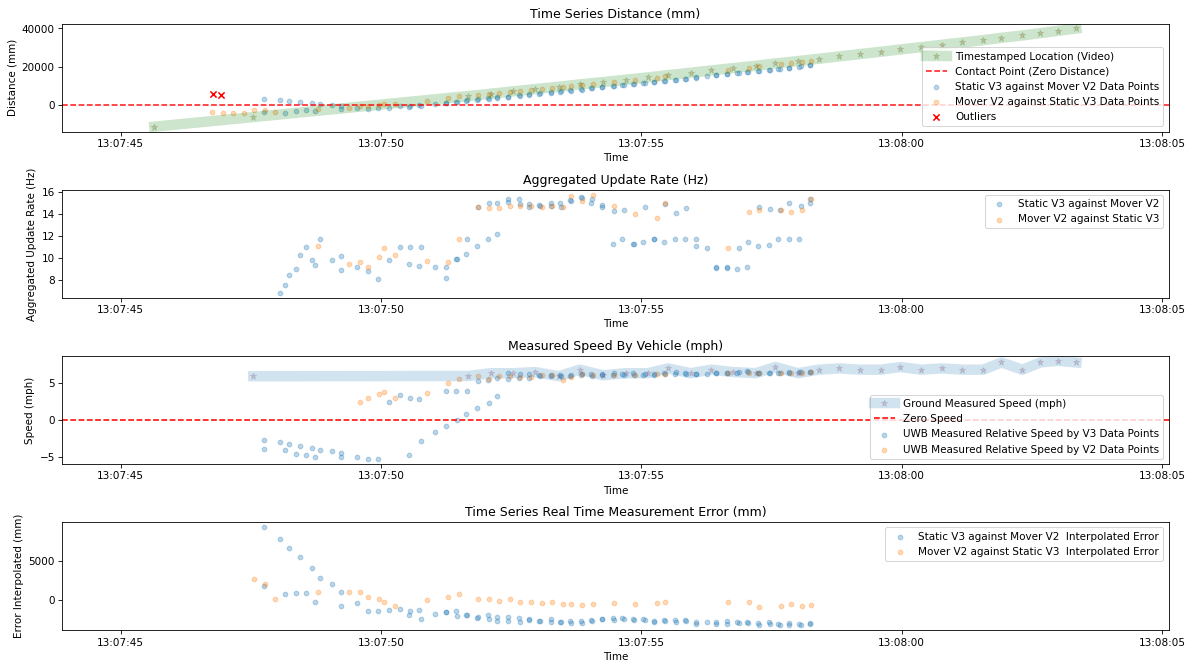

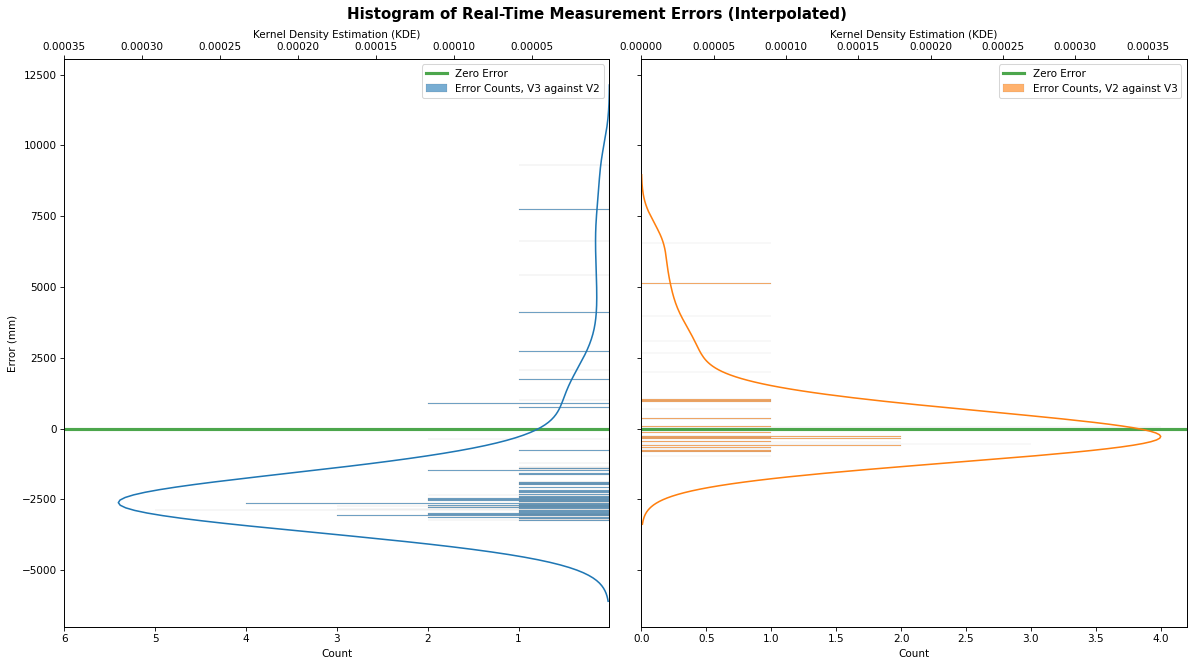

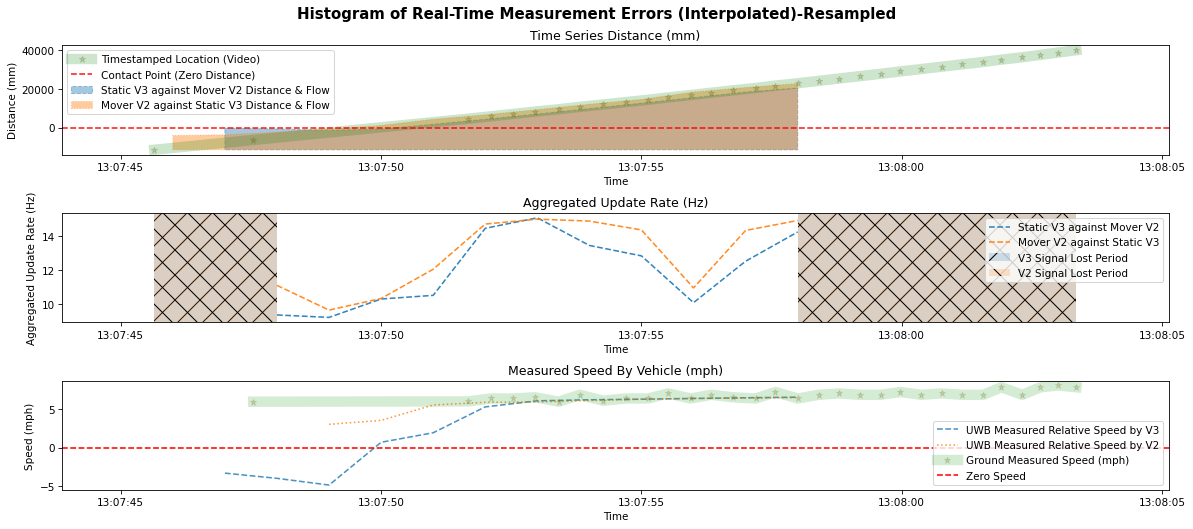

In [ ]:
test_2_west = all_test_names[2]
virtual_moving_tests[test_2_west] = parse_single_test_data(test_raw_name_file_map[test_2_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_2_west]["ground_truth"])
plot_single_test_data(test_2_west)

## 2021-05-25-13-09-08-v2-2-east-15mph

In [ ]:
test_2_east = all_test_names[3]
virtual_moving_tests[test_2_east] = parse_single_test_data(test_raw_name_file_map[test_2_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_2_east]["ground_truth"])
plot_single_test_data(test_2_east)

processing: 2021-05-25-13-09-08-v2-2-east-15mph
2021-05-25-13-09-08-v2-2-east-15mph No Data
2021-05-25-13-09-08-v2-2-east-15mph No Data, Not Plotting


## 2021-05-25-13-10-51-v2-3-west-10mph

In [ ]:
test_3_west = all_test_names[4]
virtual_moving_tests[test_3_west] = parse_single_test_data(test_raw_name_file_map[test_3_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_3_west]["ground_truth"])
plot_single_test_data(test_3_west)

processing: 2021-05-25-13-10-51-v2-3-west-10mph
2021-05-25-13-10-51-v2-3-west-10mph No Data
2021-05-25-13-10-51-v2-3-west-10mph No Data, Not Plotting


## 2021-05-25-13-12-45-v2-3-east-10mph

In [ ]:
test_3_east = all_test_names[5]
virtual_moving_tests[test_3_east] = parse_single_test_data(test_raw_name_file_map[test_3_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_3_east]["ground_truth"])
plot_single_test_data(test_3_east)

processing: 2021-05-25-13-12-45-v2-3-east-10mph
2021-05-25-13-12-45-v2-3-east-10mph No Data
2021-05-25-13-12-45-v2-3-east-10mph No Data, Not Plotting


## 2021-05-25-13-14-27-v2-4-west-20mph

processing: 2021-05-25-13-14-27-v2-4-west-20mph
plotting: 2021-05-25-13-14-27-v2-4-west-20mph


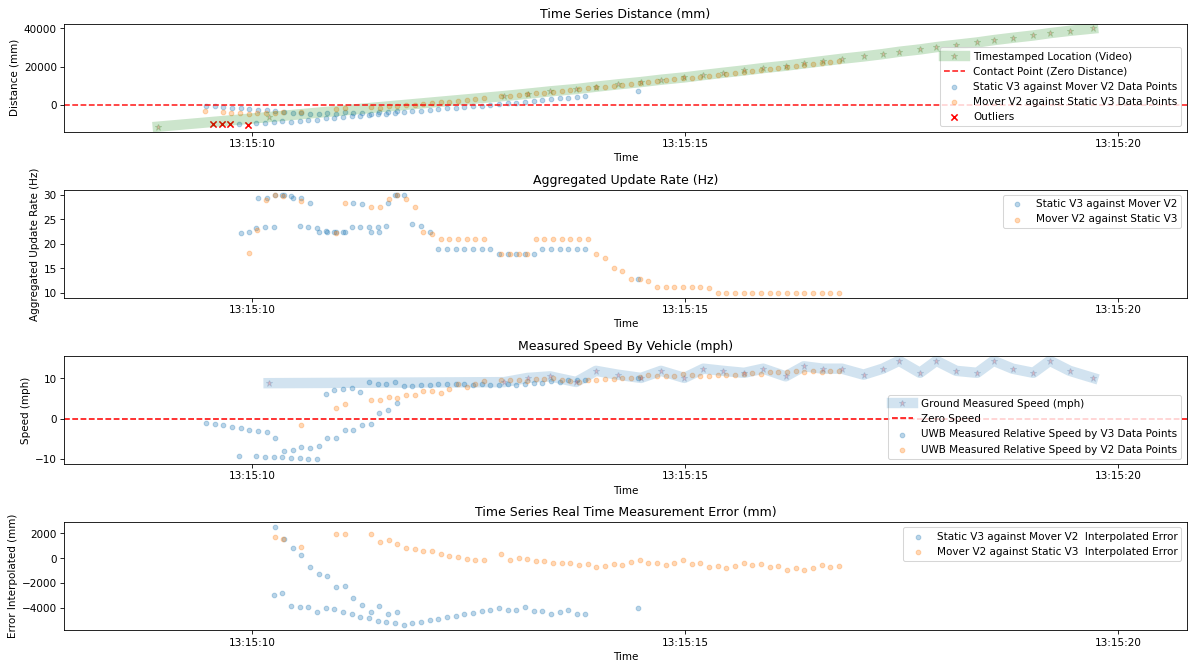

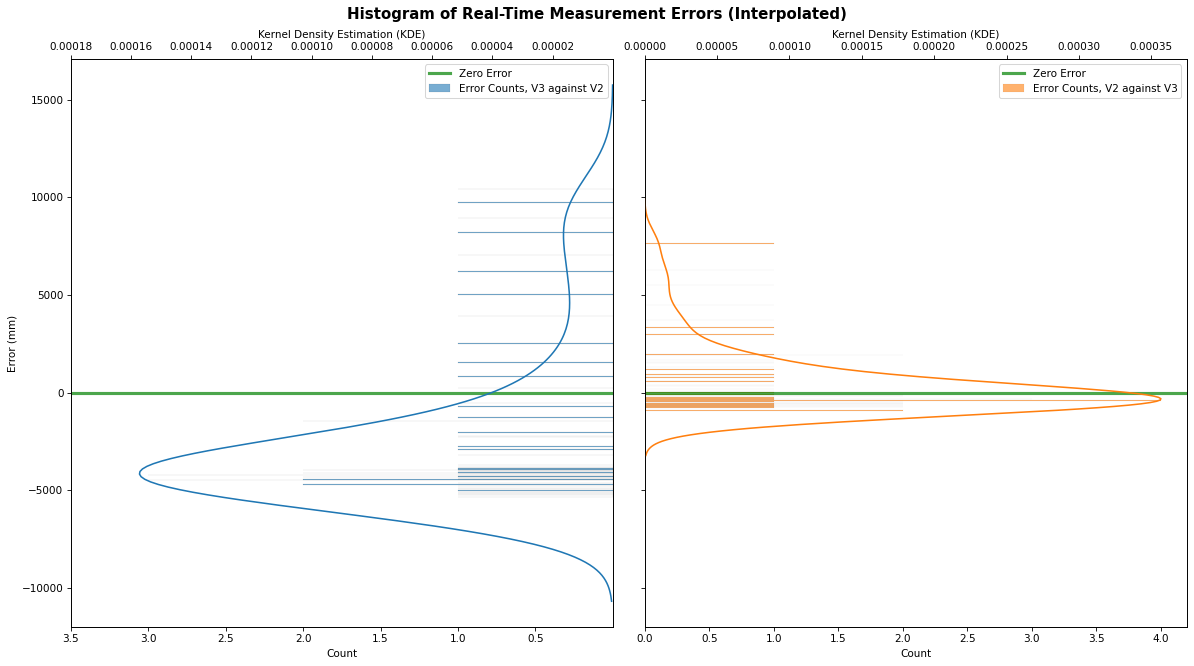

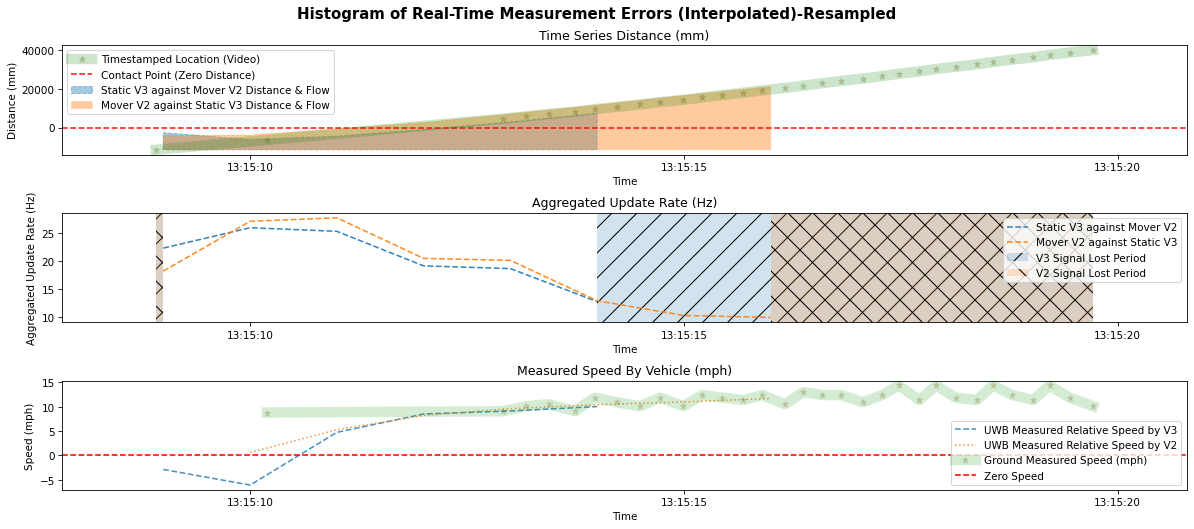

In [ ]:
test_4_west = all_test_names[6]
virtual_moving_tests[test_4_west] = parse_single_test_data(test_raw_name_file_map[test_4_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_4_west]["ground_truth"])
plot_single_test_data(test_4_west)

## 2021-05-25-13-16-54-v2-4-east-20mph

In [ ]:
test_4_east = all_test_names[7]
virtual_moving_tests[test_4_east] = parse_single_test_data(test_raw_name_file_map[test_4_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_4_east]["ground_truth"])
plot_single_test_data(test_4_east)

processing: 2021-05-25-13-16-54-v2-4-east-20mph
2021-05-25-13-16-54-v2-4-east-20mph No Data
2021-05-25-13-16-54-v2-4-east-20mph No Data, Not Plotting


## 2021-05-25-13-24-09-v2-5-west-10mph

processing: 2021-05-25-13-24-09-v2-5-west-10mph
plotting: 2021-05-25-13-24-09-v2-5-west-10mph


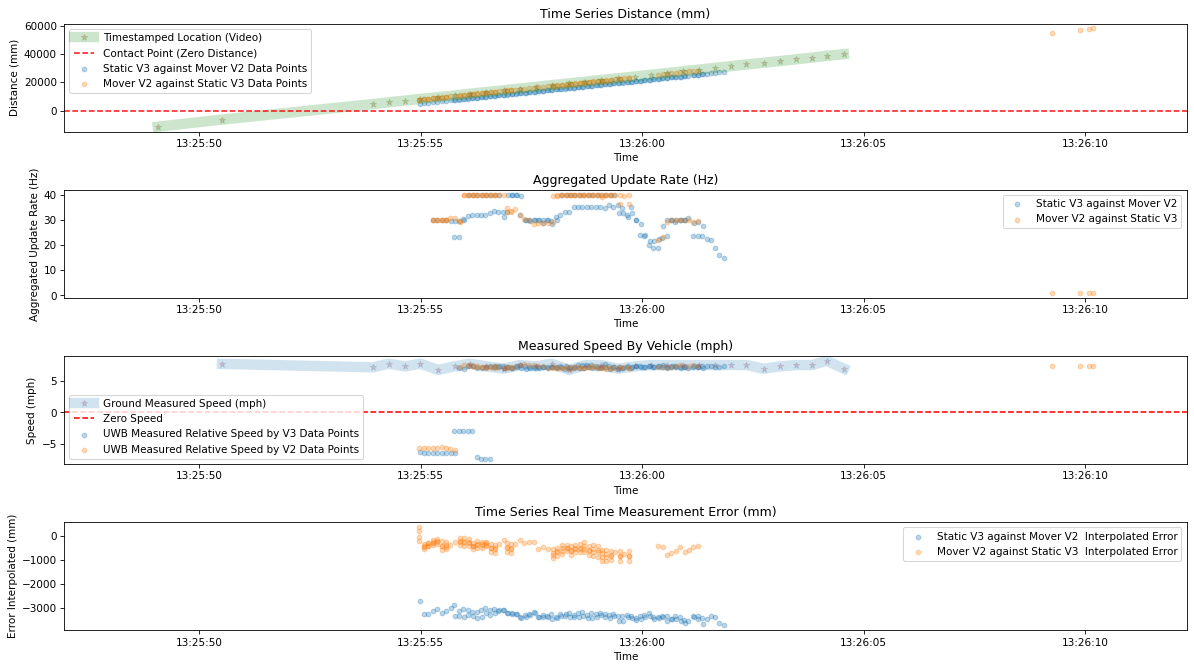

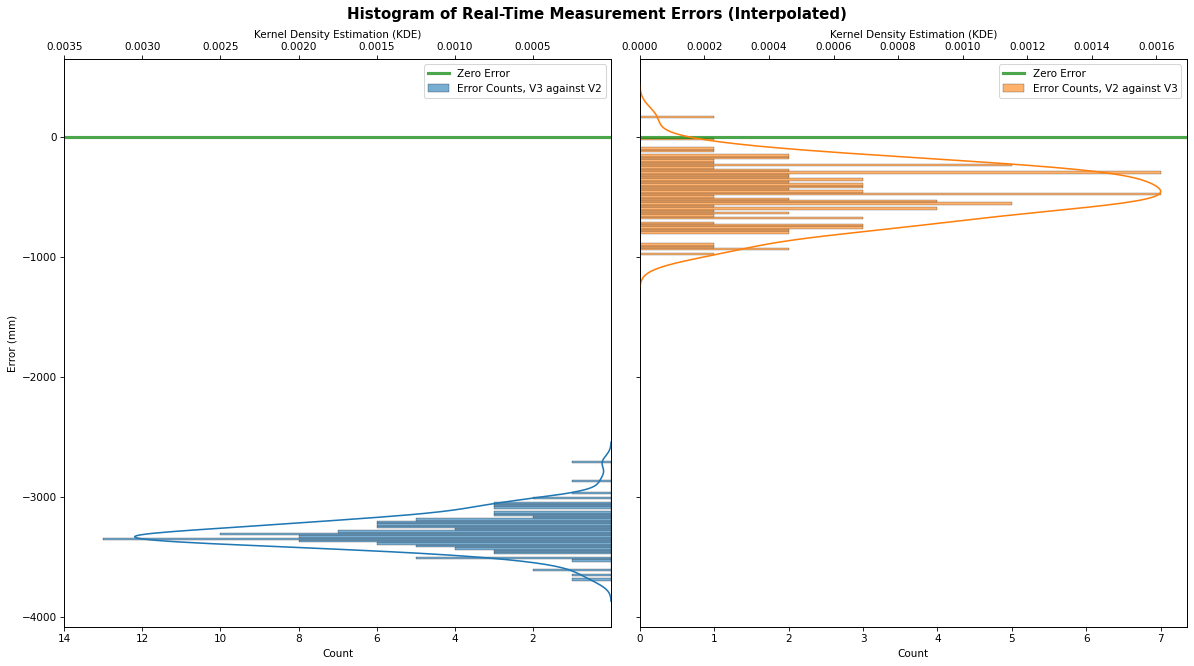

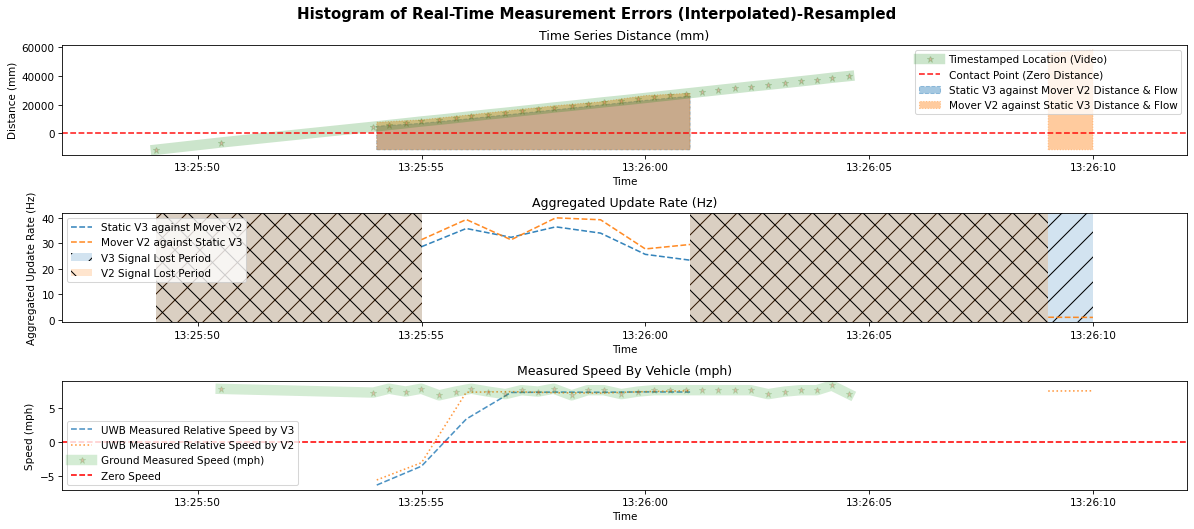

In [ ]:
test_5_west = all_test_names[8]
virtual_moving_tests[test_5_west] = parse_single_test_data(test_raw_name_file_map[test_5_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_5_west]["ground_truth"])
plot_single_test_data(test_5_west)

## 2021-05-25-13-27-19-v2-5-east-15mph

In [ ]:
test_5_east = all_test_names[9]
virtual_moving_tests[test_5_east] = parse_single_test_data(test_raw_name_file_map[test_5_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_5_east]["ground_truth"])
plot_single_test_data(test_5_east)

processing: 2021-05-25-13-27-19-v2-5-east-15mph
2021-05-25-13-27-19-v2-5-east-15mph No Data
2021-05-25-13-27-19-v2-5-east-15mph No Data, Not Plotting


## 2021-05-25-13-30-54-v2-6-west-15mph

In [ ]:
test_6_west = all_test_names[10]
virtual_moving_tests[test_6_west] = parse_single_test_data(test_raw_name_file_map[test_6_west]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_6_west]["ground_truth"])
plot_single_test_data(test_6_west)

processing: 2021-05-25-13-30-54-v2-6-west-15mph
2021-05-25-13-30-54-v2-6-west-15mph No Data
2021-05-25-13-30-54-v2-6-west-15mph No Data, Not Plotting


## 2021-05-25-13-33-14-v2-6-east-25mph

In [ ]:
test_6_east = all_test_names[11]
virtual_moving_tests[test_6_east] = parse_single_test_data(test_raw_name_file_map[test_6_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_6_east]["ground_truth"])
plot_single_test_data(test_6_east)

processing: 2021-05-25-13-33-14-v2-6-east-25mph
2021-05-25-13-33-14-v2-6-east-25mph No Data
2021-05-25-13-33-14-v2-6-east-25mph No Data, Not Plotting


## 2021-05-25-13-39-32-v2-7-west-edgepush

processing: 2021-05-25-13-39-32-v2-7-west-edgepush
plotting: 2021-05-25-13-39-32-v2-7-west-edgepush


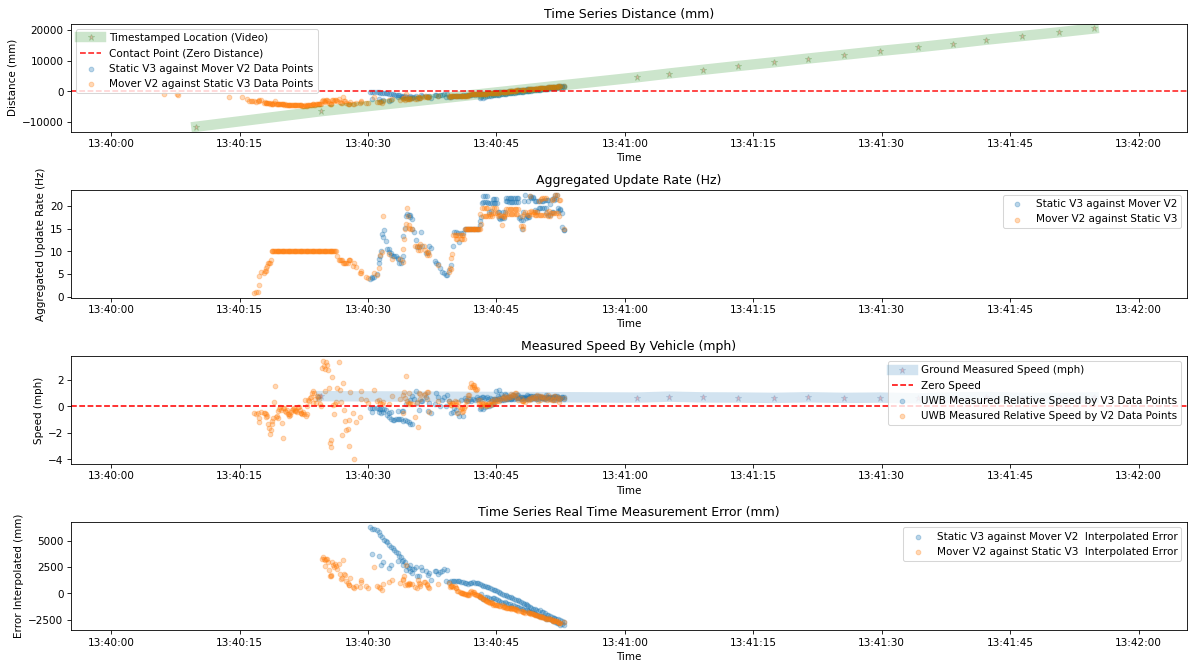

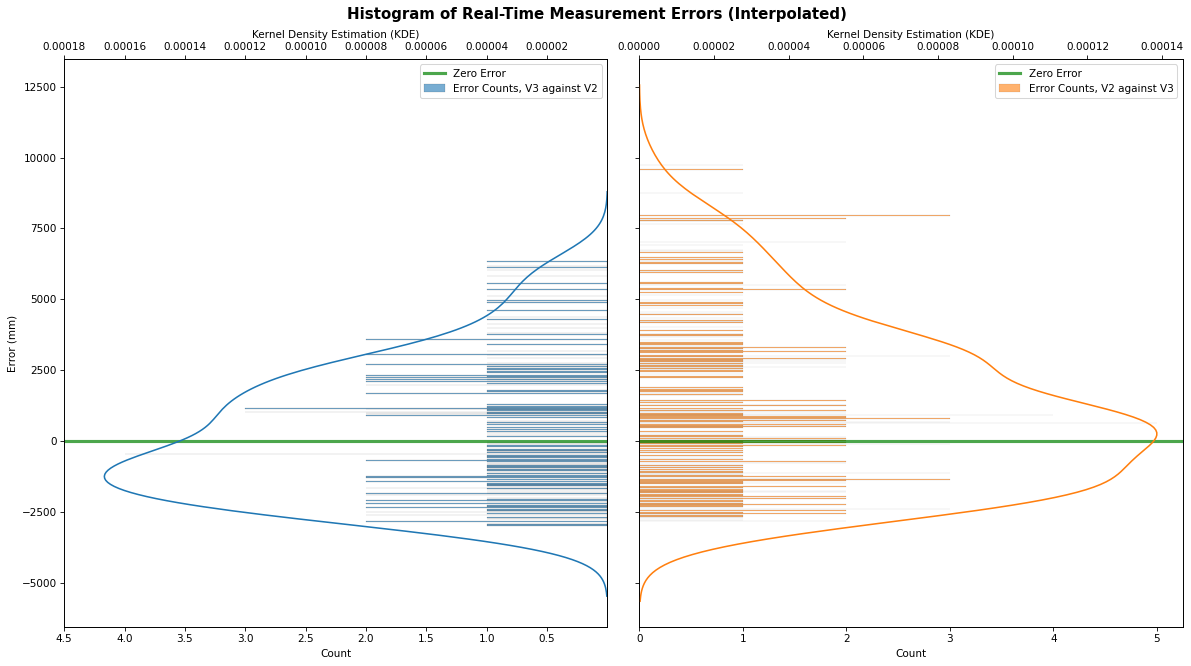

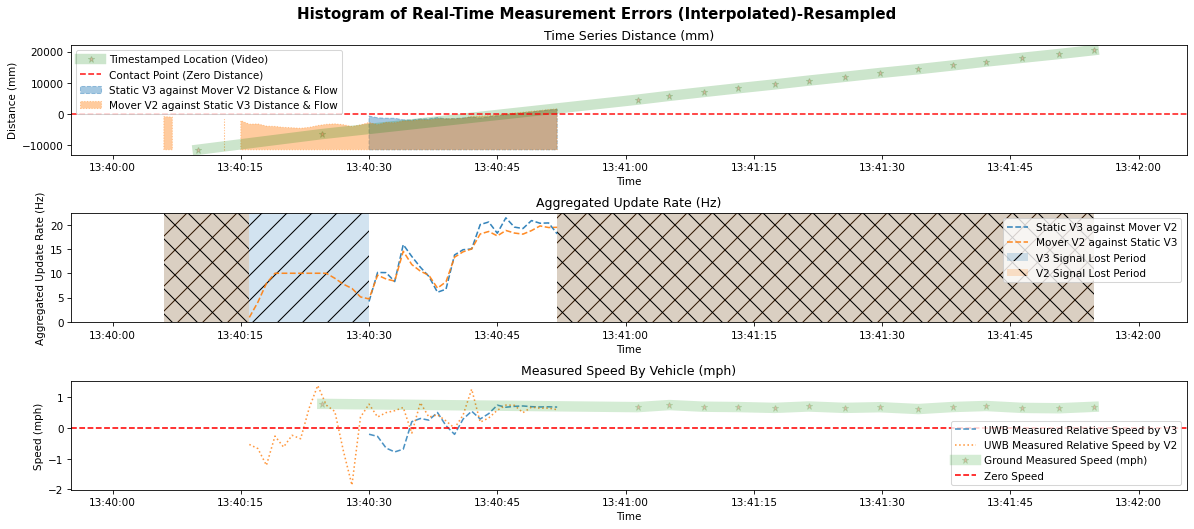

In [ ]:
test_7_west_edge_push = all_test_names[12]
virtual_moving_tests[test_7_west_edge_push] = parse_single_test_data(test_raw_name_file_map[test_7_west_edge_push]["B"], "Virtual Moving Test", 
                                                                     test_raw_name_file_map[test_7_west_edge_push]["ground_truth"])
plot_single_test_data(test_7_west_edge_push)

## 2021-05-25-13-42-27-v2-edgepush-seg

In [ ]:
test_7_west_edge_push_seg = all_test_names[13]
virtual_moving_tests[test_7_west_edge_push_seg] = parse_single_test_data(test_raw_name_file_map[test_7_west_edge_push_seg]["B"], "Virtual Moving Test", 
                                                                         test_raw_name_file_map[test_7_west_edge_push_seg]["ground_truth"])
plot_single_test_data(test_7_west_edge_push_seg)

processing: 2021-05-25-13-42-27-v2-edgepush-seg
2021-05-25-13-42-27-v2-edgepush-seg No Data
2021-05-25-13-42-27-v2-edgepush-seg No Data, Not Plotting


## 2021-05-25-13-46-51-v2-8-edgepush-seg

In [ ]:
test_8_edge_push_seg_1 = all_test_names[14]
virtual_moving_tests[test_8_edge_push_seg_1] = parse_single_test_data(test_raw_name_file_map[test_8_edge_push_seg_1]["B"], "Virtual Moving Test", 
                                                                      test_raw_name_file_map[test_8_edge_push_seg_1]["ground_truth"])
plot_single_test_data(test_8_edge_push_seg_1)

processing: 2021-05-25-13-46-51-v2-8-edgepush-seg
2021-05-25-13-46-51-v2-8-edgepush-seg No Data
2021-05-25-13-46-51-v2-8-edgepush-seg No Data, Not Plotting


## 2021-05-25-13-48-43-v2-edgepush-seg

In [ ]:
test_8_edge_push_seg_2 = all_test_names[15]
virtual_moving_tests[test_8_edge_push_seg_2] = parse_single_test_data(test_raw_name_file_map[test_8_edge_push_seg_2]["B"], "Virtual Moving Test", 
                                                                      test_raw_name_file_map[test_8_edge_push_seg_2]["ground_truth"])
plot_single_test_data(test_8_edge_push_seg_2)

processing: 2021-05-25-13-48-43-v2-edgepush-seg
2021-05-25-13-48-43-v2-edgepush-seg No Data
2021-05-25-13-48-43-v2-edgepush-seg No Data, Not Plotting


## 2021-05-25-13-49-31-v2-edgepush-seg

processing: 2021-05-25-13-49-31-v2-edgepush-seg


No handles with labels found to put in legend.
No handles with labels found to put in legend.


plotting: 2021-05-25-13-49-31-v2-edgepush-seg


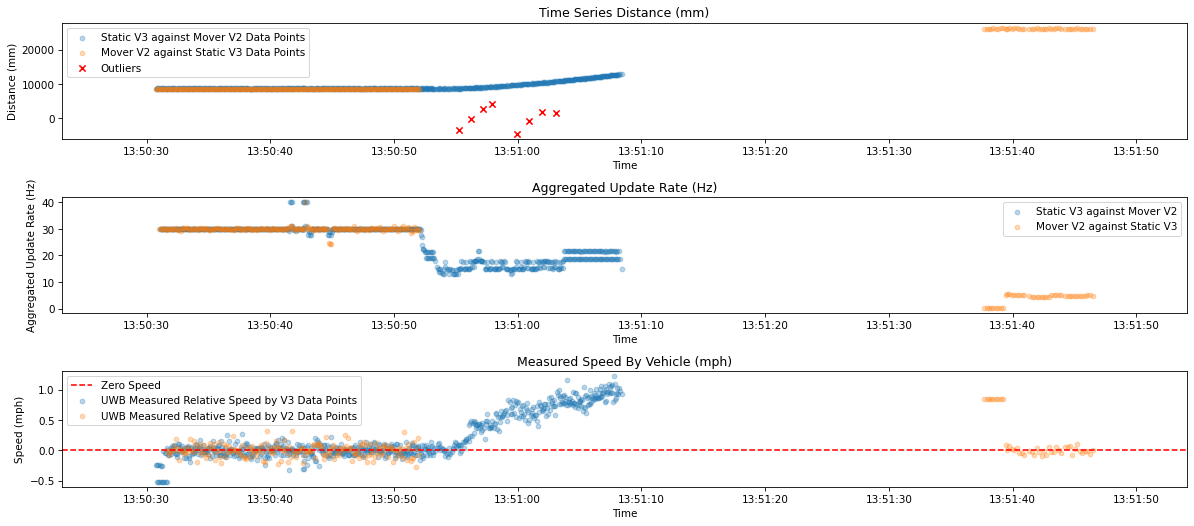

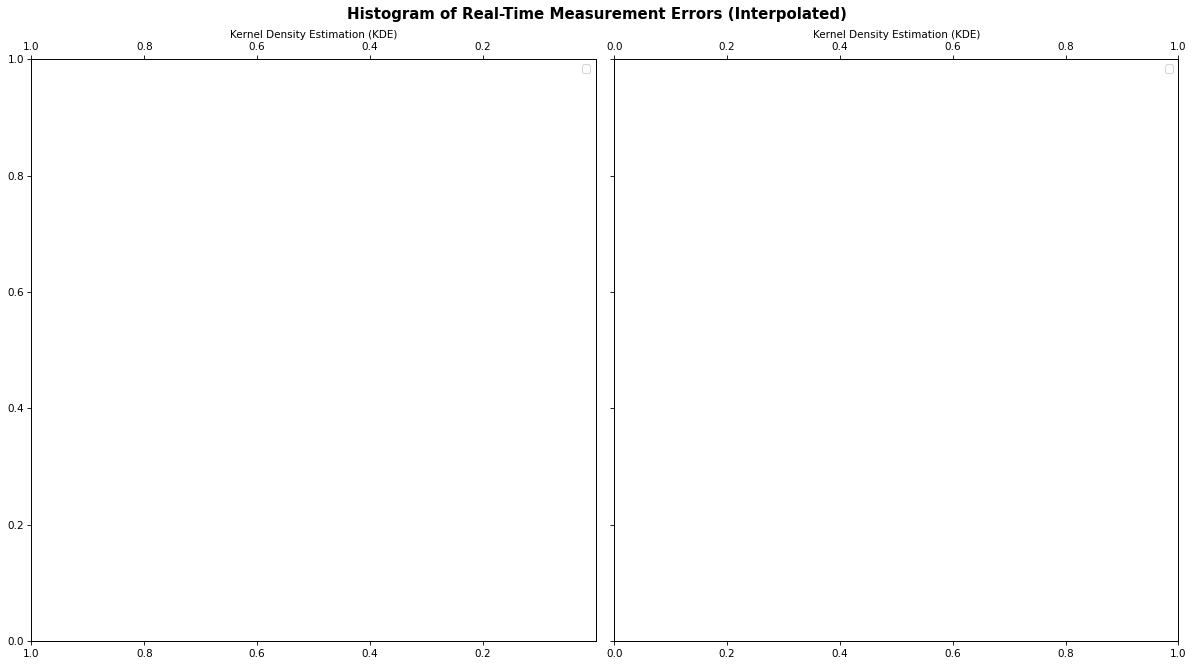

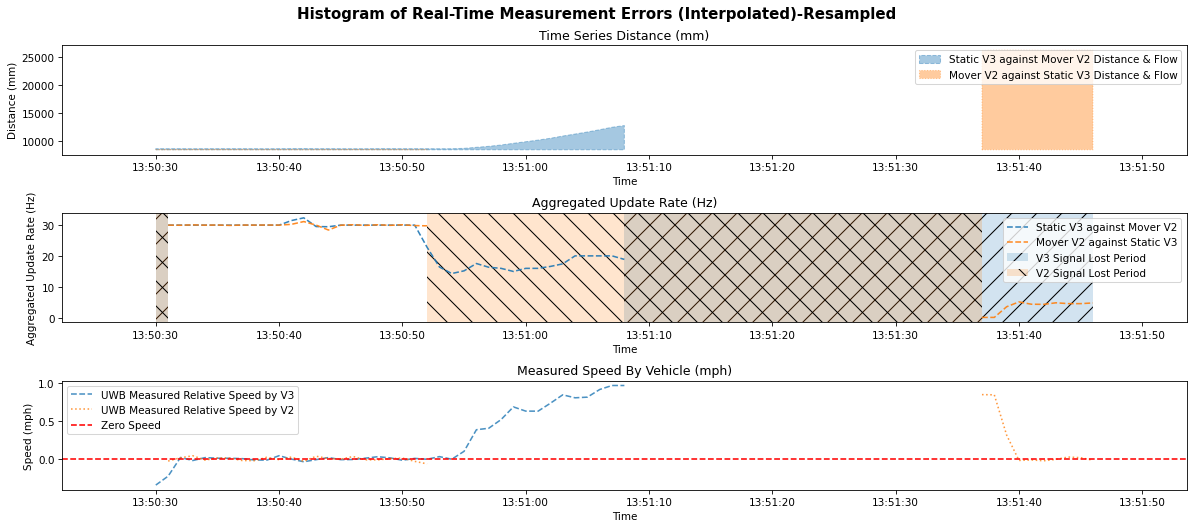

In [ ]:
test_8_edge_push_seg_3 = all_test_names[16]
virtual_moving_tests[test_8_edge_push_seg_3] = parse_single_test_data(test_raw_name_file_map[test_8_edge_push_seg_3]["B"], "Virtual Moving Test", 
                                                                      test_raw_name_file_map[test_8_edge_push_seg_3]["ground_truth"])
plot_single_test_data(test_8_edge_push_seg_3)

## 2021-05-25-13-51-49-v2-edgepush-seg

In [ ]:
test_8_edge_push_seg_4 = all_test_names[17]
virtual_moving_tests[test_8_edge_push_seg_4] = parse_single_test_data(test_raw_name_file_map[test_8_edge_push_seg_4]["B"], "Virtual Moving Test", 
                                                                      test_raw_name_file_map[test_8_edge_push_seg_4]["ground_truth"])
plot_single_test_data(test_8_edge_push_seg_4)

processing: 2021-05-25-13-51-49-v2-edgepush-seg
2021-05-25-13-51-49-v2-edgepush-seg No Data
2021-05-25-13-51-49-v2-edgepush-seg No Data, Not Plotting


## 2021-05-25-13-52-07-v2-9-east

In [ ]:
test_9_east = all_test_names[18]
virtual_moving_tests[test_9_east] = parse_single_test_data(test_raw_name_file_map[test_9_east]["B"], "Virtual Moving Test", 
                                                           test_raw_name_file_map[test_9_east]["ground_truth"])
plot_single_test_data(test_9_east)

processing: 2021-05-25-13-52-07-v2-9-east
plotting: 2021-05-25-13-52-07-v2-9-east


UnboundLocalError: local variable 'df_static_time_idx' referenced before assignment

<Figure size 1200x675 with 0 Axes>

In [ ]:
virtual_moving_tests[test_9_east][2]

{'df_veh_time_idx':                               Initiating Master Master Side  \
 Datetime Normalized                                           
 2021-05-25 13:52:10.024120064              88BA           B   
 2021-05-25 13:52:10.316546048              88BA           B   
 2021-05-25 13:52:10.416617984              88BA           B   
 2021-05-25 13:52:10.515892992              88BA           B   
 2021-05-25 13:52:10.616538112              88BA           B   
 ...                                         ...         ...   
 2021-05-25 13:52:26.415540992              88BA           B   
 2021-05-25 13:52:26.516790016              88BA           B   
 2021-05-25 13:52:26.616102912              88BA           B   
 2021-05-25 13:52:26.715790080              88BA           B   
 2021-05-25 13:52:29.012541952              88BA           B   
 
                                Reporting Master X (mm)  \
 Datetime Normalized                                      
 2021-05-25 13:52:10.02412006